## Similarity vs. Globality Anaysis
Here we analyze the dependance of the similarity metric on globality 

In [68]:
import os
# change to platonic-rep root directory
# os.chdir(r'c:\Users\user\OneDrive - Technion\Documents\GitHub\platonic-rep')
os.chdir(r'c:\Users\barweiss\OneDrive - Technion\Documents\GitHub\platonic-rep')

In [69]:
import numpy as np  
import matplotlib.pyplot as plt
import utils 
from tasks import get_models

import pandas as pd
import seaborn as sns

sim_params = {
    'modelset': 'val',
    'dataset': 'minhuh\\prh',
    'subset': 'wit_1024',
    'modality_x': 'vision',
    'modality_y': 'vision',
    'pool_x': 'cls',
    'pool_y': 'cls',
    'prompt_x': False,
    'prompt_y': False,
    'metric': 'cknna',
    'sweep_len': 40,
    'layer_mode': 'final',
}

# sim_params = {
#     'modelset': 'val',
#     'dataset': 'minhuh\\prh',
#     'subset': 'wit_1024',
#     'modality_x': 'language',
#     'modality_y': 'language',
#     'pool_x': 'avg',
#     'pool_y': 'avg',
#     'prompt_x': False,
#     'prompt_y': False,
#     'metric': 'diffusion_cka',
#     'sweep_len': 30,
#     'layer_mode': 'final',
# }

# sim_params = {
#     'modelset': 'val',
#     'dataset': 'minhuh\\prh',
#     'subset': 'wit_1024',
#     'modality_x': 'language',
#     'modality_y': 'vision',
#     'pool_x': 'avg',
#     'pool_y': 'cls',
#     'prompt_x': False,
#     'prompt_y': False,
#     'metric': 'diffusion_cka',
#     'sweep_len': 30,
#     'layer_mode': 'final',
# }

# plotting params
fontsize = 16

# get alignment data path
results_dir = os.path.join('results', 'alignment')
load_path = utils.to_alignment_filename(
            results_dir, sim_params['dataset'], sim_params['modelset'],
            sim_params['modality_x'], sim_params['pool_x'], sim_params['prompt_x'],
            sim_params['modality_y'], sim_params['pool_y'], sim_params['prompt_y'],
            sim_params['metric'], sim_params['sweep_len'], layer_mode=sim_params['layer_mode']
    )

# define figure path
figure_path = os.path.join('post_processing', 'figures', f'{sim_params["modelset"]}_{sim_params["subset"]}', 
                           f'{sim_params["metric"]}_layer_{sim_params["layer_mode"]}', 
                           f'{sim_params["modality_x"]}_vs_{sim_params["modality_y"]}')
os.makedirs(figure_path, exist_ok=True)

# load alignment data
data = np.load(load_path, allow_pickle=True).item()

In [70]:
n_models = data['scores'].shape[0]
llm_models, lvm_models = get_models(sim_params['modelset'], modality='all')
model_names_x = llm_models if sim_params['modality_x'] == "language" else lvm_models
model_names_y = llm_models if sim_params['modality_y'] == "language" else lvm_models

In [71]:
print(model_names_x)
print(model_names_y)

['vit_tiny_patch16_224.augreg_in21k', 'vit_small_patch16_224.augreg_in21k', 'vit_base_patch16_224.augreg_in21k', 'vit_large_patch16_224.augreg_in21k', 'vit_base_patch16_224.mae', 'vit_large_patch16_224.mae', 'vit_huge_patch14_224.mae', 'vit_small_patch14_dinov2.lvd142m', 'vit_base_patch14_dinov2.lvd142m', 'vit_large_patch14_dinov2.lvd142m', 'vit_giant_patch14_dinov2.lvd142m', 'vit_base_patch16_clip_224.laion2b', 'vit_large_patch14_clip_224.laion2b', 'vit_huge_patch14_clip_224.laion2b', 'vit_base_patch16_clip_224.laion2b_ft_in12k', 'vit_large_patch14_clip_224.laion2b_ft_in12k', 'vit_huge_patch14_clip_224.laion2b_ft_in12k']
['vit_tiny_patch16_224.augreg_in21k', 'vit_small_patch16_224.augreg_in21k', 'vit_base_patch16_224.augreg_in21k', 'vit_large_patch16_224.augreg_in21k', 'vit_base_patch16_224.mae', 'vit_large_patch16_224.mae', 'vit_huge_patch14_224.mae', 'vit_small_patch14_dinov2.lvd142m', 'vit_base_patch14_dinov2.lvd142m', 'vit_large_patch14_dinov2.lvd142m', 'vit_giant_patch14_dinov2.l

In [72]:
model_names_map = {
    # vision models
    'vit_tiny_patch16_224.augreg_in21k': 'AugReg-tiny',
    'vit_small_patch16_224.augreg_in21k': 'AugReg-small',
    'vit_base_patch16_224.augreg_in21k': 'AugReg-base',
    'vit_large_patch16_224.augreg_in21k': 'AugReg-large',
    'vit_base_patch16_224.mae': 'MAE-base',
    'vit_large_patch16_224.mae': 'MAE-large',
    'vit_huge_patch14_224.mae': 'MAE-huge',
    'vit_small_patch14_dinov2.lvd142m': 'DINOv2-small',
    'vit_base_patch14_dinov2.lvd142m': 'DINOv2-base',
    'vit_large_patch14_dinov2.lvd142m': 'DINOv2-large',
    'vit_giant_patch14_dinov2.lvd142m': 'DINOv2-giant',
    'vit_base_patch16_clip_224.laion2b': 'CLIP-base',
    'vit_large_patch14_clip_224.laion2b': 'CLIP-large',
    'vit_huge_patch14_clip_224.laion2b': 'CLIP-huge',
    'vit_base_patch16_clip_224.laion2b_ft_in12k': 'CLIP-base-ft',
    'vit_large_patch14_clip_224.laion2b_ft_in12k': 'CLIP-large-ft',
    'vit_huge_patch14_clip_224.laion2b_ft_in12k': 'CLIP-huge-ft',
    # language models
    'bigscience/bloomz-560m': 'BLOOMZ-560M',
    'bigscience/bloomz-1b1': 'BLOOMZ-1B1',
    'bigscience/bloomz-1b7': 'BLOOMZ-1B7',
    'bigscience/bloomz-3b': 'BLOOMZ-3B',
    'bigscience/bloomz-7b1': 'BLOOMZ-7B1',
    'openlm-research/open_llama_3b': 'OpenLLaMA-3B',
    'openlm-research/open_llama_7b': 'OpenLLaMA-7B',
    'openlm-research/open_llama_13b': 'OpenLLaMA-13B',
    'huggyllama/llama-7b': 'HuggyLLaMA-7B',
    'huggyllama/llama-13b': 'HuggyLLaMA-13B',
    'huggyllama/llama-30b': 'HuggyLLaMA-30B',
    'huggyllama/llama-65b': 'HuggyLLaMA-65B',

}

In [73]:
# plot alignment vs. topk values for models in model list
vision_model_families = ['augreg', 'mae', 'dinov2', 'clip']
language_model_families = ['bloomz', 'open_llama', 'huggyllama']


In [74]:
def plot_similarity_globality(
        data, 
        model_names_x: list[str], 
        model_names_y: list[str],
        model_family_x: str, 
        model_family_y: str, 
        figure_path: str,
        fontsize=16,
        log_scale=False):
    """
    Plot similarity vs. globality for models in specified families.
    
    Args:
        log_scale: If True, use logarithmic scale for x-axis
    """
    
    sweep_vec = data['param_vec']
    param_name = data['param_name']
    same_family = model_family_x == model_family_y
    # filter models by family if model name conatins the family string
    model_list_x = [m for m in model_names_x if model_family_x in m]
    model_list_y = [m for m in model_names_y if model_family_y in m]
    # print(f"Plotting {model_family_x} vs. {model_family_y}:")
    # print(f"  Models X: {model_list_x}")
    # print(f"  Models Y: {model_list_y}")
    model_pairs = []
    plt.figure(figsize=(10,6))
    for i, model_x in enumerate(model_list_x):
        model_x_idx = model_names_x.index(model_x)
        for j, model_y in enumerate(model_list_y):
            model_y_idx = model_names_y.index(model_y)
            if same_family and i == j:
                continue
            if (model_y, model_x) in model_pairs:
                continue
            model_pairs.append((model_x, model_y))
            alignment_scores = data['scores'][model_x_idx, model_y_idx, :]
            label = f"{model_names_map.get(model_x, model_x)} vs. {model_names_map.get(model_y, model_y)}"
            plt.plot(sweep_vec, alignment_scores, marker='o', label=label)

    plt.xlabel(f'Globality[{param_name}]', fontsize=fontsize)
    plt.ylabel(f'{sim_params["metric"]} score', fontsize=fontsize)
    plt.xticks(fontsize=fontsize-2)
    plt.yticks(fontsize=fontsize-2)
    
    # Set log scale if requested
    if log_scale:
        plt.xscale('log')
    
    plt.grid(True)
    plt.legend(fontsize=fontsize)
    plt.savefig(f'{figure_path}/sim_globality_{model_family_x}_vs_{model_family_y}.png', dpi=300)

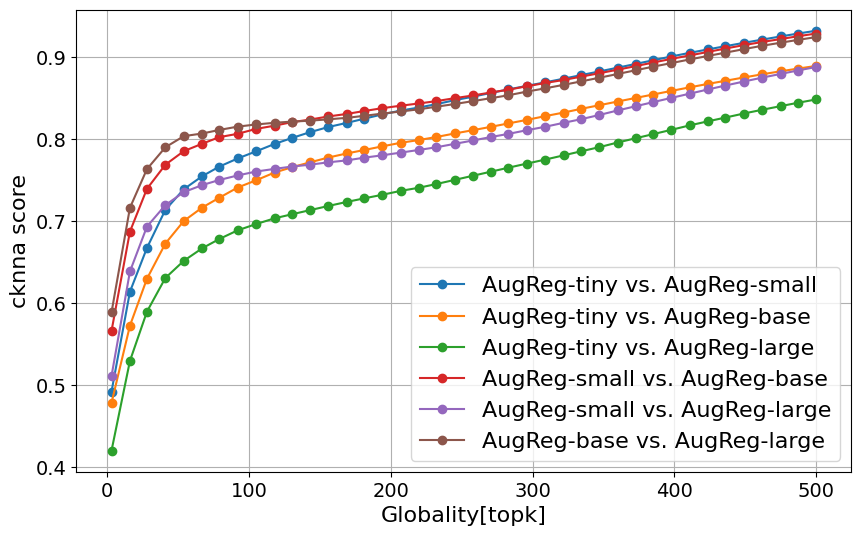

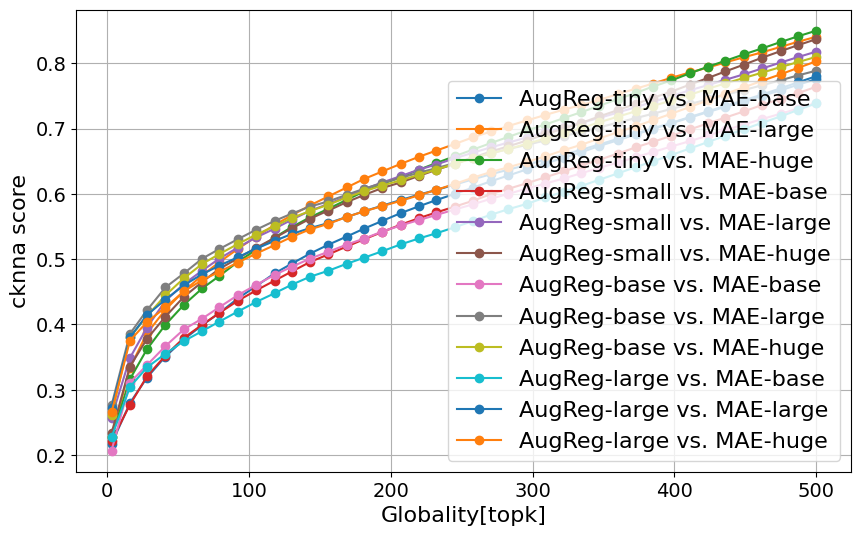

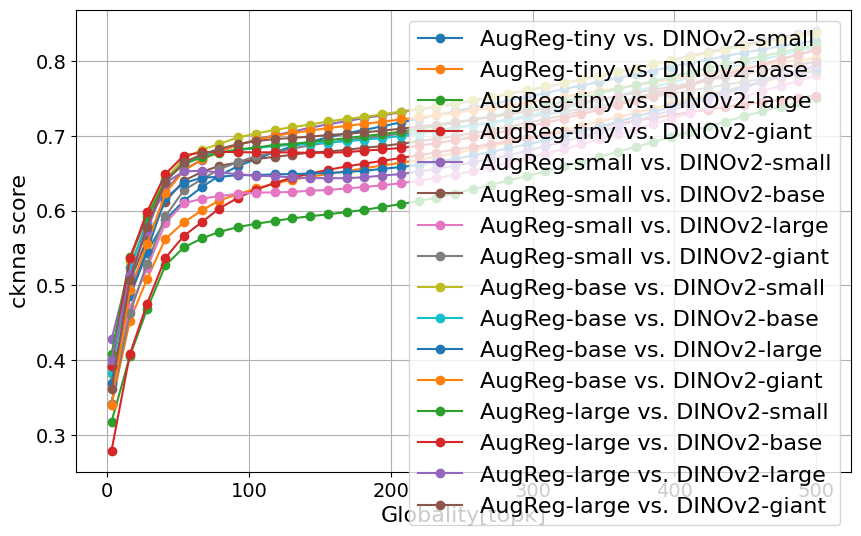

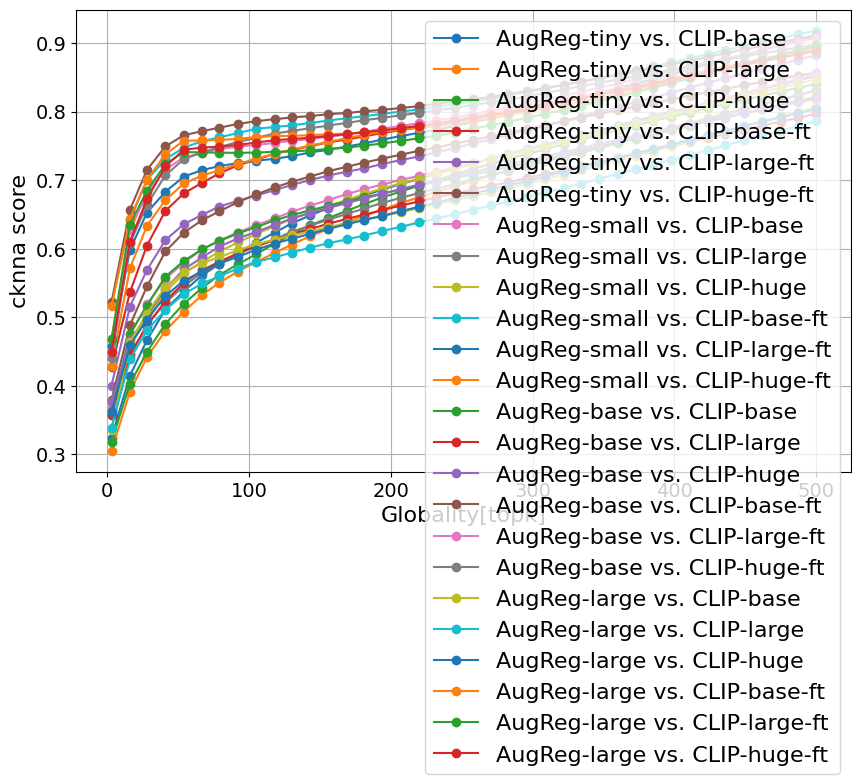

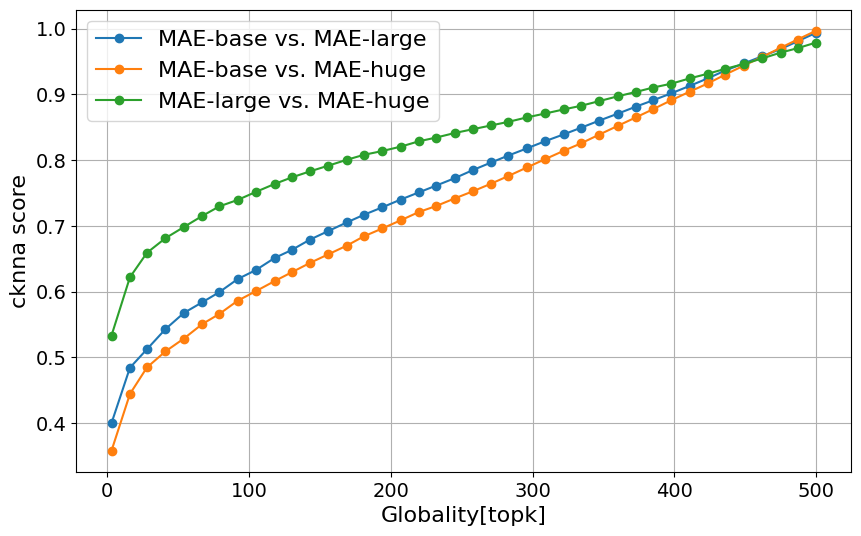

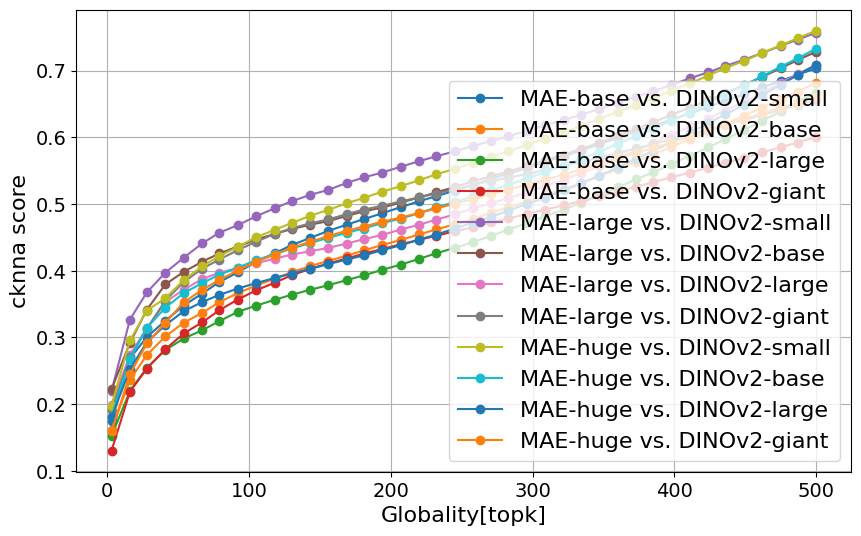

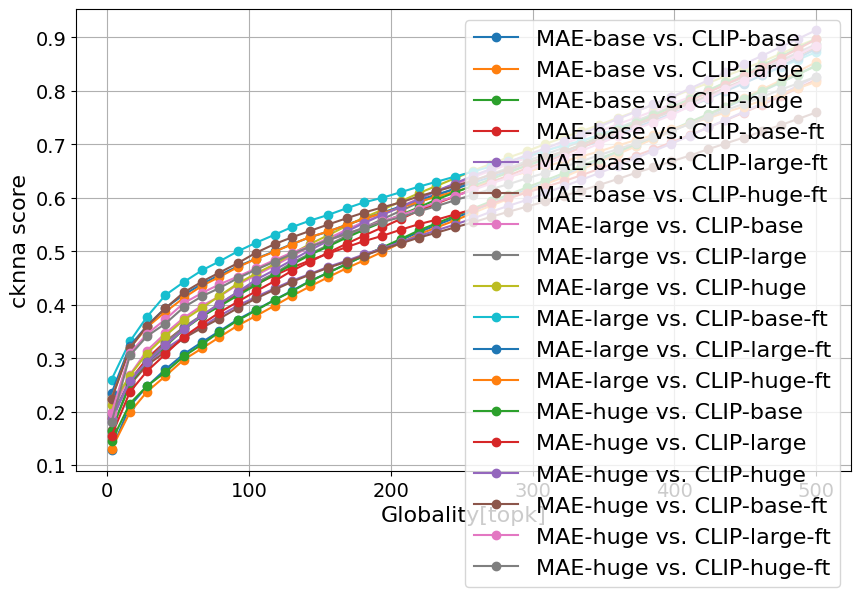

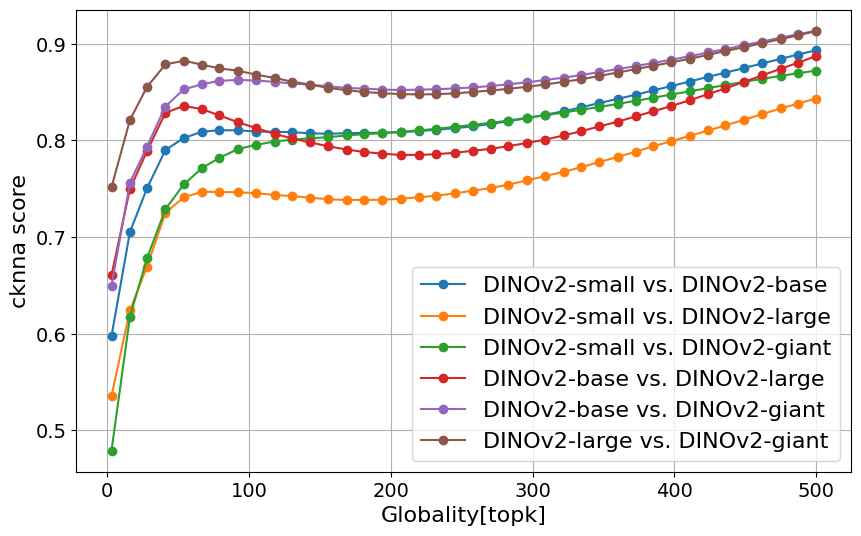

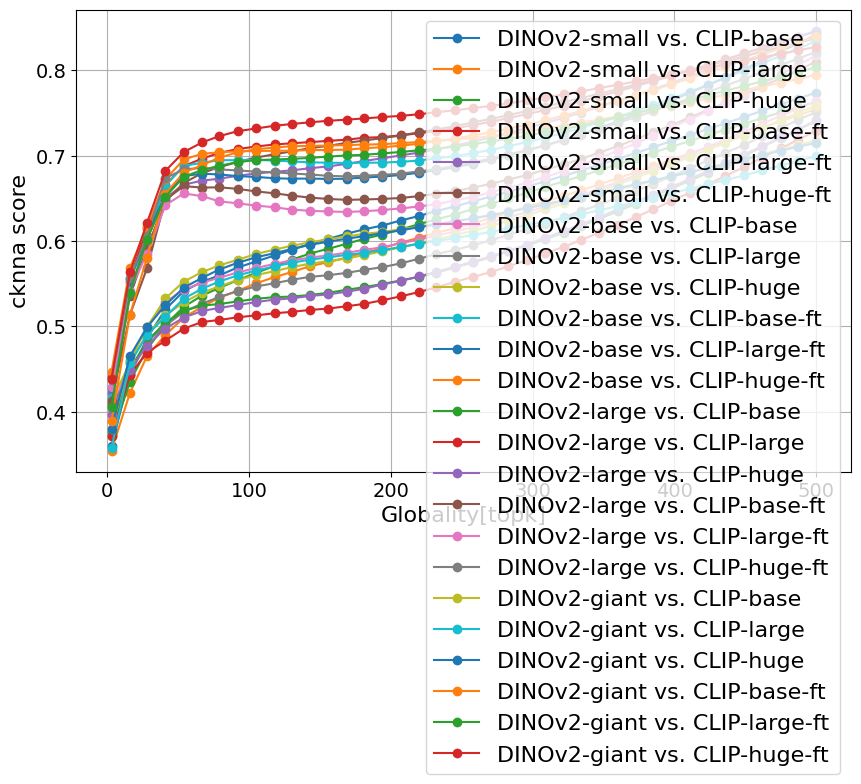

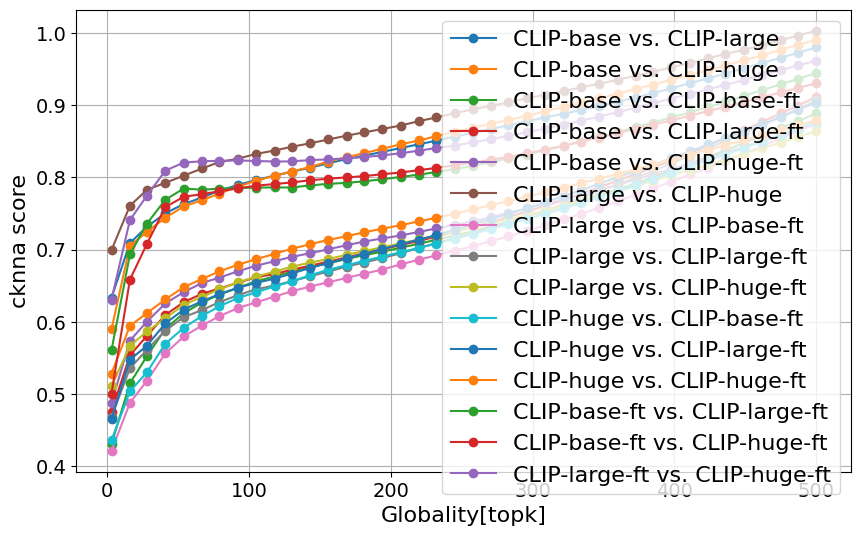

In [80]:
families_x = vision_model_families if sim_params['modality_x'] == "vision" else language_model_families
families_y = vision_model_families if sim_params['modality_y'] == "vision" else language_model_families

# use log scale if sweep_vec is not evenely spaced
sweep_vec = data['param_vec']
# log_scale = not np.allclose(np.diff(sweep_vec), np.diff(sweep_vec)[0])
log_scale = False 

# plot similarity vs. globality for each unique family pair
family_pairs = []
for fam_x in families_x:
    for fam_y in families_y:
        if (fam_y, fam_x) in family_pairs:
            continue
        family_pairs.append((fam_x, fam_y))
        plot_similarity_globality(
            data, model_names_x, model_names_y,
            fam_x, fam_y,
            figure_path,
            fontsize=fontsize,
            log_scale=log_scale  # Enable logarithmic x-axis
        )

## Aggregate Analysis: Total Variation vs. Median & Max vs. Min Similarity
Compute total variation (weighted by sweep parameter spacing) and similarity statistics for each model pair

In [76]:
def compute_aggregates(data, model_names_x, model_names_y, model_family_x, model_family_y):
    """
    Compute total variation, convexity, AUC, and similarity statistics for model pairs.
    
    Total Variation: sum of |dy/dx| * |dx| where dy is the change in similarity
                     and dx is the change in sweep parameter
    Convexity: sum of second derivatives (measures curvature)
    AUC: Area Under Curve using trapezoidal integration
    Median Similarity: median similarity across all globality values
    Max Similarity: maximum similarity across all globality values
    Min Similarity: minimum similarity across all globality values
    """
    same_family = model_family_x == model_family_y
    model_list_x = [m for m in model_names_x if model_family_x in m]
    model_list_y = [m for m in model_names_y if model_family_y in m]
    
    sweep_vec = data['param_vec']
    results = []
    model_pairs = []
    
    for i, model_x in enumerate(model_list_x):
        model_x_idx = model_names_x.index(model_x)
        for j, model_y in enumerate(model_list_y):
            model_y_idx = model_names_y.index(model_y)
            
            # Skip same model pairs and duplicates
            if same_family and i == j:
                continue
            if (model_y, model_x) in model_pairs:
                continue
            
            model_pairs.append((model_x, model_y))
            alignment_scores = data['scores'][model_x_idx, model_y_idx, :]
            
            # Compute metrics
            # Total variation: sum of |dy/dx| * |dx|
            dy = np.diff(alignment_scores)
            # dx = np.diff(sweep_vec)
            # total_variation = np.sum(np.abs(dy / dx) * np.abs(dx))  # simplifies to np.sum(np.abs(dy))
            # But we keep it explicit to show we're considering the sweep parameter
            total_variation = np.sum(np.abs(dy))  # Since dx cancels out
            
            # Convexity: sum of second derivatives
            # Second derivative approximation: d²y/dx² ≈ (y[i+1] - 2*y[i] + y[i-1]) / dx²
            dy = np.diff(alignment_scores) 
            dx = np.diff(sweep_vec)
            d2y = np.diff(dy / dx) / dx[:-1]
            convexity = np.sum(d2y)  # Sum of second derivatives (positive = convex, negative = concave)
            
            # Area Under Curve: using trapezoidal rule
            auc = np.trapezoid(alignment_scores, sweep_vec)
            
            median_similarity = np.median(alignment_scores)
            max_similarity = np.max(alignment_scores)
            min_similarity = np.min(alignment_scores)
            mean_similarity = np.mean(alignment_scores)
            
            label = f"{model_names_map.get(model_x, model_x)} vs. {model_names_map.get(model_y, model_y)}"
            
            results.append({
                'model_pair': label,
                'model_x': model_names_map.get(model_x, model_x),
                'model_y': model_names_map.get(model_y, model_y),
                'family_x': model_family_x,
                'family_y': model_family_y,
                'total_variation': total_variation,
                'convexity': convexity,
                'auc': auc,
                'median_similarity': median_similarity,
                'max_similarity': max_similarity,
                'min_similarity': min_similarity,
                'mean_similarity': mean_similarity
            })
    
    return pd.DataFrame(results)

In [77]:
# Compute aggregates for all family pairs
all_aggregates = []

for fam_x, fam_y in family_pairs:
    df = compute_aggregates(data, model_names_x, model_names_y, fam_x, fam_y)
    all_aggregates.append(df)

# Combine all results
aggregates_df = pd.concat(all_aggregates, ignore_index=True)
print(f"Total model pairs analyzed: {len(aggregates_df)}")
aggregates_df.head(10)

Total model pairs analyzed: 136


,model_pair,model_x,model_y,family_x,family_y,total_variation,convexity,auc,median_similarity,max_similarity,min_similarity,mean_similarity
0,AugReg-tiny vs. AugReg-small,AugReg-tiny,AugReg-small,augreg,augreg,0.440466,-0.000708,414.472173,0.849708,0.932359,0.491893,0.830883
1,AugReg-tiny vs. AugReg-base,AugReg-tiny,AugReg-base,augreg,augreg,0.411237,-0.000548,394.767987,0.808969,0.889362,0.478125,0.791512
2,AugReg-tiny vs. AugReg-large,AugReg-tiny,AugReg-large,augreg,augreg,0.428648,-0.000637,369.309061,0.752829,0.848457,0.419809,0.740336
3,AugReg-small vs. AugReg-base,AugReg-small,AugReg-base,augreg,augreg,0.363006,-0.000714,420.745299,0.851690,0.928925,0.565919,0.844090
4,AugReg-small vs. AugReg-large,AugReg-small,AugReg-large,augreg,augreg,0.377241,-0.000747,395.349670,0.796357,0.888101,0.510860,0.793076
5,AugReg-base vs. AugReg-large,AugReg-base,AugReg-large,augreg,augreg,0.336049,-0.000748,420.571507,0.844659,0.924562,0.588513,0.843983
6,AugReg-tiny vs. MAE-base,AugReg-tiny,MAE-base,augreg,mae,0.558711,-0.000324,288.412643,0.604796,0.775722,0.217011,0.578185
7,AugReg-tiny vs. MAE-large,AugReg-tiny,MAE-large,augreg,mae,0.613169,-0.000595,323.895359,0.681559,0.840691,0.227522,0.648743
8,AugReg-tiny vs. MAE-huge,AugReg-tiny,MAE-huge,augreg,mae,0.622692,-0.000483,317.752603,0.662804,0.849984,0.227292,0.636806
9,AugReg-small vs. MAE-base,AugReg-small,MAE-base,augreg,mae,0.542659,-0.000280,281.597285,0.584994,0.764013,0.221354,0.564725


Saved figure to: post_processing\figures\val_wit_1024\cknna_layer_final\vision_vs_vision\aggregate_tv_vs_median_similarity.png


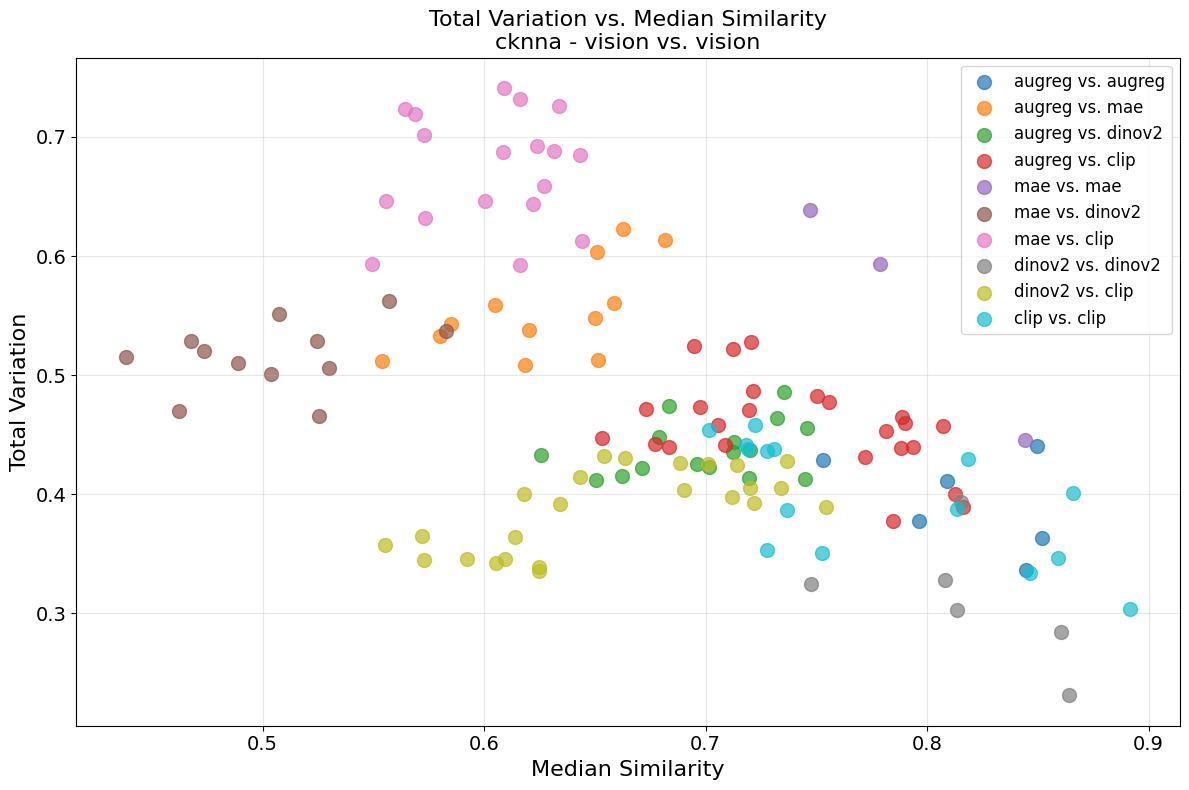

Saved figure to: post_processing\figures\val_wit_1024\cknna_layer_final\vision_vs_vision\aggregate_range_vs_mean_similarity.png


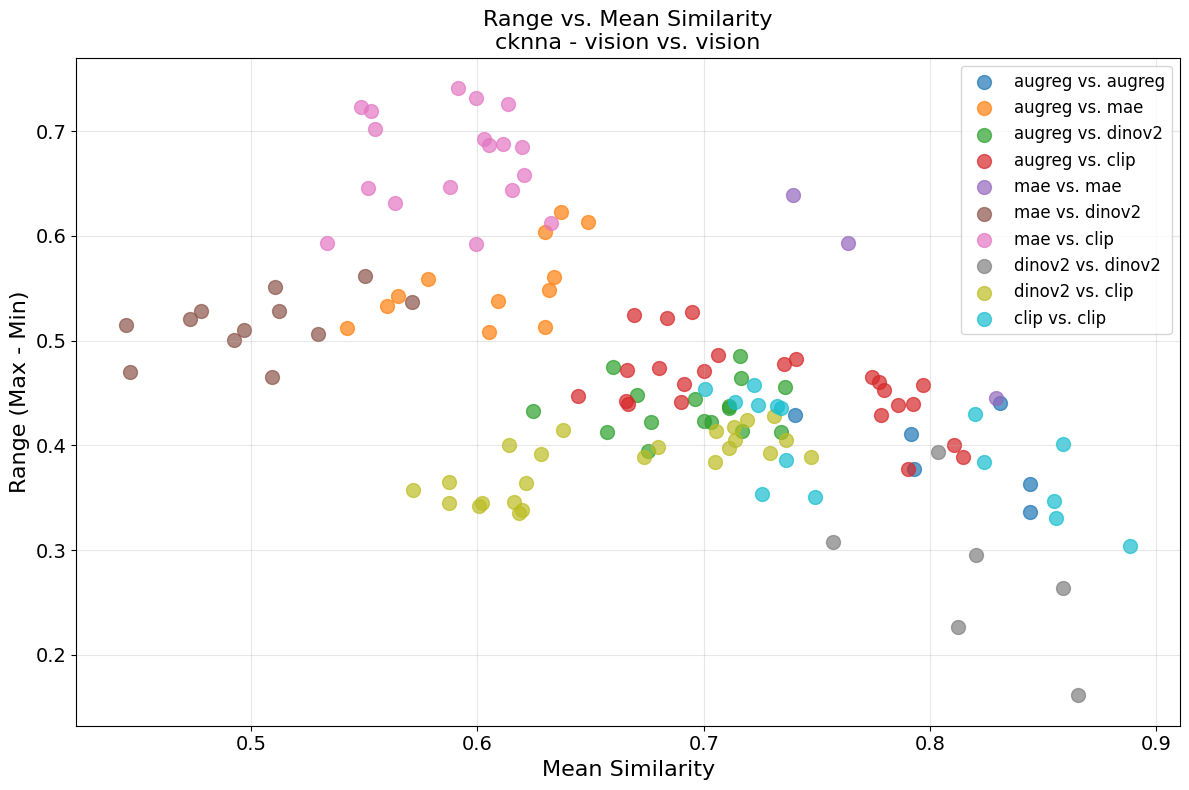

Saved figure to: post_processing\figures\val_wit_1024\cknna_layer_final\vision_vs_vision\aggregate_convexity_vs_median_similarity.png


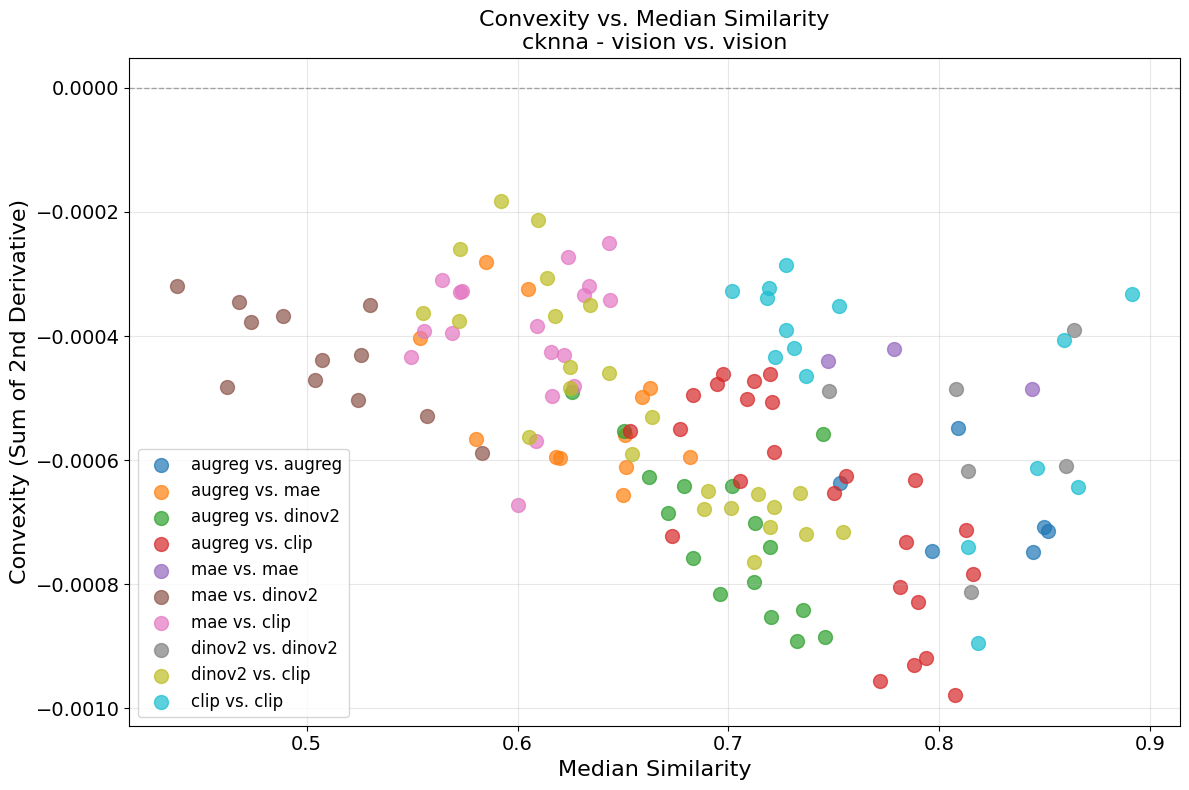

Saved figure to: post_processing\figures\val_wit_1024\cknna_layer_final\vision_vs_vision\aggregate_tv_vs_auc.png


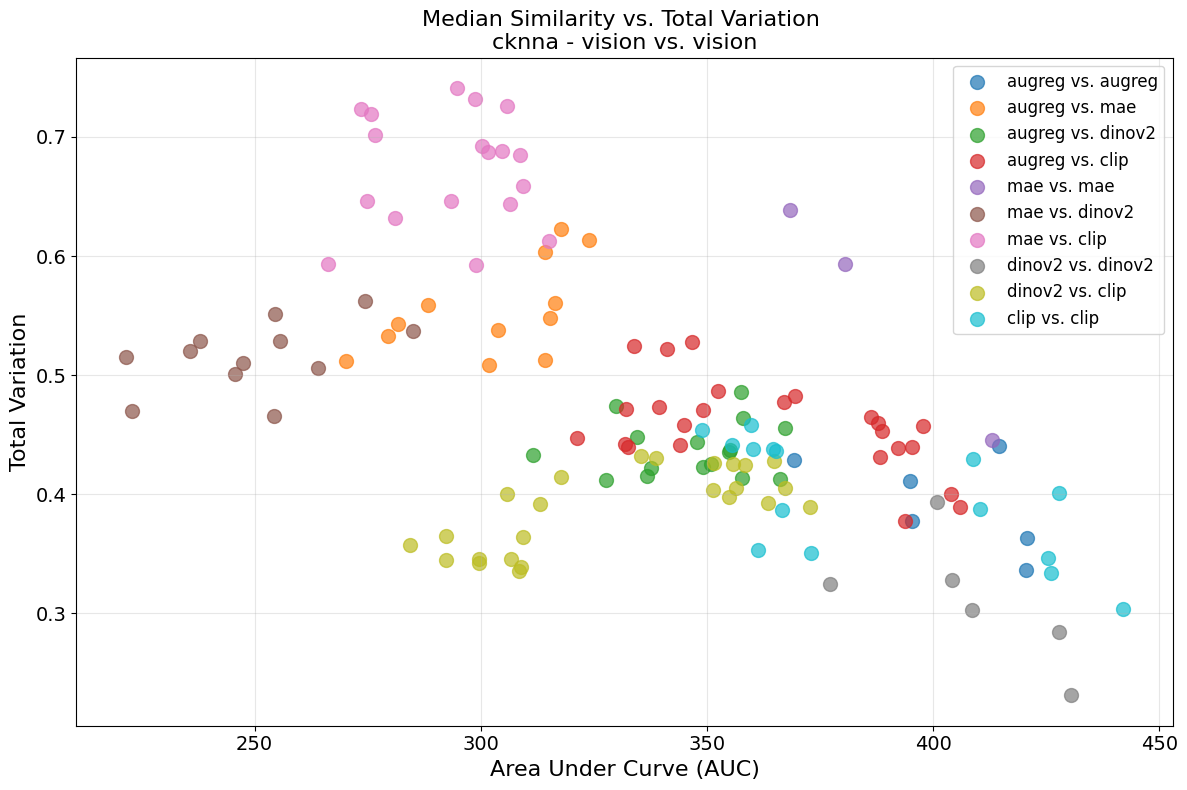

In [78]:
# Create scatter plots

# Color by family pair combinations
family_pair_labels = aggregates_df['family_x'] + ' vs. ' + aggregates_df['family_y']
unique_pairs = family_pair_labels.unique()

# Use a color palette
colors = sns.color_palette('tab10', n_colors=len(unique_pairs))
color_map = {pair: colors[i] for i, pair in enumerate(unique_pairs)}

# Calculate range (max - min)
aggregates_df['range'] = aggregates_df['max_similarity'] - aggregates_df['min_similarity']

# Plot 1: Total Variation vs. Median Similarity
plt.figure(figsize=(12, 8))
for pair in unique_pairs:
    mask = family_pair_labels == pair
    subset = aggregates_df[mask]
    plt.scatter(subset['median_similarity'], subset['total_variation'], 
               label=pair, alpha=0.7, s=100, color=color_map[pair])

plt.xlabel('Median Similarity', fontsize=fontsize)
plt.ylabel('Total Variation', fontsize=fontsize)
plt.title(f'Total Variation vs. Median Similarity\n{sim_params["metric"]} - {sim_params["modality_x"]} vs. {sim_params["modality_y"]}', 
         fontsize=fontsize)
plt.xticks(fontsize=fontsize-2)
plt.yticks(fontsize=fontsize-2)
plt.legend(fontsize=fontsize-4, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
save_path = os.path.join(figure_path, 'aggregate_tv_vs_median_similarity.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved figure to: {save_path}")
plt.show()

# Plot 2: Range (Max-Min) vs. Mean Similarity
plt.figure(figsize=(12, 8))
for pair in unique_pairs:
    mask = family_pair_labels == pair
    subset = aggregates_df[mask]
    plt.scatter(subset['mean_similarity'], subset['range'], 
               label=pair, alpha=0.7, s=100, color=color_map[pair])

plt.xlabel('Mean Similarity', fontsize=fontsize)
plt.ylabel('Range (Max - Min)', fontsize=fontsize)
plt.title(f'Range vs. Mean Similarity\n{sim_params["metric"]} - {sim_params["modality_x"]} vs. {sim_params["modality_y"]}', 
         fontsize=fontsize)
plt.xticks(fontsize=fontsize-2)
plt.yticks(fontsize=fontsize-2)
plt.legend(fontsize=fontsize-4, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
save_path = os.path.join(figure_path, 'aggregate_range_vs_mean_similarity.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved figure to: {save_path}")
plt.show()

# Plot 3: Convexity vs. Median Similarity
plt.figure(figsize=(12, 8))
for pair in unique_pairs:
    mask = family_pair_labels == pair
    subset = aggregates_df[mask]
    plt.scatter(subset['median_similarity'], subset['convexity'], 
               label=pair, alpha=0.7, s=100, color=color_map[pair])

plt.xlabel('Median Similarity', fontsize=fontsize)
plt.ylabel('Convexity (Sum of 2nd Derivative)', fontsize=fontsize)
plt.title(f'Convexity vs. Median Similarity\n{sim_params["metric"]} - {sim_params["modality_x"]} vs. {sim_params["modality_y"]}', 
         fontsize=fontsize)
plt.xticks(fontsize=fontsize-2)
plt.yticks(fontsize=fontsize-2)
plt.legend(fontsize=fontsize-4, loc='best')
plt.grid(True, alpha=0.3)
# Add horizontal line at y=0 to show convex/concave boundary
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3, linewidth=1)
plt.tight_layout()

# Save figure
save_path = os.path.join(figure_path, 'aggregate_convexity_vs_median_similarity.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved figure to: {save_path}")
plt.show()

# Plot 4: AUC vs. Median Similarity
plt.figure(figsize=(12, 8))
for pair in unique_pairs:
    mask = family_pair_labels == pair
    subset = aggregates_df[mask]
    plt.scatter(subset['auc'], subset['total_variation'], 
               label=pair, alpha=0.7, s=100, color=color_map[pair])

plt.xlabel('Area Under Curve (AUC)', fontsize=fontsize)
plt.ylabel('Total Variation', fontsize=fontsize)
plt.title(f'Median Similarity vs. Total Variation \n{sim_params["metric"]} - {sim_params["modality_x"]} vs. {sim_params["modality_y"]}', 
         fontsize=fontsize)
plt.xticks(fontsize=fontsize-2)
plt.yticks(fontsize=fontsize-2)
plt.legend(fontsize=fontsize-4, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
save_path = os.path.join(figure_path, 'aggregate_tv_vs_auc.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved figure to: {save_path}")
plt.show()

In [79]:
# Summary statistics
print("\nSummary Statistics:")
print("=" * 80)
print(f"Median Similarity: {aggregates_df['median_similarity'].mean():.4f} ± {aggregates_df['median_similarity'].std():.4f}")
print(f"Mean Similarity:   {aggregates_df['mean_similarity'].mean():.4f} ± {aggregates_df['mean_similarity'].std():.4f}")
print(f"Max Similarity:    {aggregates_df['max_similarity'].mean():.4f} ± {aggregates_df['max_similarity'].std():.4f}")
print(f"Min Similarity:    {aggregates_df['min_similarity'].mean():.4f} ± {aggregates_df['min_similarity'].std():.4f}")
print(f"Total Variation:   {aggregates_df['total_variation'].mean():.4f} ± {aggregates_df['total_variation'].std():.4f}")
print(f"Convexity:         {aggregates_df['convexity'].mean():.4f} ± {aggregates_df['convexity'].std():.4f}")

print(f"\nCorrelation between Median Similarity and Total Variation: {aggregates_df['median_similarity'].corr(aggregates_df['total_variation']):.4f}")
print(f"Correlation between Median Similarity and Convexity: {aggregates_df['median_similarity'].corr(aggregates_df['convexity']):.4f}")
print(f"Correlation between Max and Min Similarity: {aggregates_df['max_similarity'].corr(aggregates_df['min_similarity']):.4f}")

# Count convex vs concave curves
n_convex = (aggregates_df['convexity'] > 0).sum()
n_concave = (aggregates_df['convexity'] < 0).sum()
print(f"\nConvex curves (positive 2nd derivative sum): {n_convex}")
print(f"Concave curves (negative 2nd derivative sum): {n_concave}")

print("\nTop 5 pairs by Median Similarity:")
print(aggregates_df.nlargest(5, 'median_similarity')[['model_pair', 'median_similarity', 'total_variation', 'convexity', 'max_similarity', 'min_similarity']])

print("\nTop 5 pairs by Total Variation (most variable):")
print(aggregates_df.nlargest(5, 'total_variation')[['model_pair', 'median_similarity', 'total_variation', 'convexity', 'max_similarity', 'min_similarity']])

print("\nTop 5 pairs by Min Total Variation (most stable):")
print(aggregates_df.nsmallest(5, 'total_variation')[['model_pair', 'median_similarity', 'total_variation', 'convexity', 'max_similarity', 'min_similarity']])

print("\nTop 5 pairs by Convexity (most convex):")
print(aggregates_df.nlargest(5, 'convexity')[['model_pair', 'median_similarity', 'total_variation', 'convexity', 'max_similarity', 'min_similarity']])

print("\nTop 5 pairs by Convexity (most concave):")
print(aggregates_df.nsmallest(5, 'convexity')[['model_pair', 'median_similarity', 'total_variation', 'convexity', 'max_similarity', 'min_similarity']])

print("\nTop 5 pairs by Max-Min Range (most sensitive to globality):")
aggregates_df['range'] = aggregates_df['max_similarity'] - aggregates_df['min_similarity']
print(aggregates_df.nlargest(5, 'range')[['model_pair', 'median_similarity', 'total_variation', 'convexity', 'max_similarity', 'min_similarity', 'range']])


Summary Statistics:
Median Similarity: 0.6839 ± 0.0984
Mean Similarity:   0.6775 ± 0.0995
Max Similarity:    0.8321 ± 0.0759
Min Similarity:    0.3634 ± 0.1349
Total Variation:   0.4714 ± 0.1068
Convexity:         -0.0005 ± 0.0002

Correlation between Median Similarity and Total Variation: -0.4951
Correlation between Median Similarity and Convexity: -0.5197
Correlation between Max and Min Similarity: 0.5734

Convex curves (positive 2nd derivative sum): 0
Concave curves (negative 2nd derivative sum): 136

Top 5 pairs by Median Similarity:
                        model_pair  median_similarity  total_variation  \
126       CLIP-large vs. CLIP-huge           0.891558         0.303814   
122        CLIP-base vs. CLIP-huge           0.865989         0.400856   
96   DINOv2-large vs. DINOv2-giant           0.863937         0.231103   
95    DINOv2-base vs. DINOv2-giant           0.860340         0.284566   
121       CLIP-base vs. CLIP-large           0.859026         0.346609   

     conve